# ECGR 4105 Midterm Project 1

**Group members:** Jordan Mckoy, Miguel Diaz-Alvarez, AJ Carroll

### Import Libaries and Load Data

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

### Data Preprocessing

In [9]:
RANDOM_STATE = 42
data = load_breast_cancer()
X, y = data.data, data.target
display(pd.DataFrame(X, columns=data.feature_names).head())
display(pd.DataFrame(y, columns=["target"]).head())

X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y
    )
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,target
0,0
1,0
2,0
3,0
4,0


### Evaluate Model Helper

In [10]:
def evaluate(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=data.target_names).plot(cmap=plt.cm.Blues)
    plt.title(name)
    plt.show()
    print(classification_report(y_test, y_pred, target_names=data.target_names))
    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "recall_malignant": recall_score(y_test, y_pred, pos_label=0),
    }

### GridSearch Summarizer

In [ ]:
def summarize_grid(grid, name):
    print(f"{name} — best params: {grid.best_params_}")
    print(f"{name} — best CV score: {grid.best_score_:.4f}")
    cv = pd.DataFrame(grid.cv_results_)
    if "param_scaler" in cv.columns:
        summary = (cv.groupby(cv["param_scaler"].astype(str))["mean_test_score"]
                     .agg(["max", "mean"]).round(4)
                     .sort_values("max", ascending=False))
        display(summary)
    return cv

### Scorer
This scorer returns a weighted recall score by placing more emphasis on 
the malignant recall. This is because in a medical context more value should be placed on false negatives as this could lead to a patient not getting treatment when needed.

In [12]:
def weighted_recall(y_true, y_pred, w_m = 0.6, w_b = 0.4):
    recall_m = recall_score(y_true, y_pred, pos_label=0)
    recall_b = recall_score(y_true, y_pred, pos_label=1)
    return (w_m * recall_m) + (w_b * recall_b)


### Logistic Regression

Logistic Regression — best params: {'clf__C': 1, 'clf__max_iter': 2000, 'clf__solver': 'liblinear', 'scaler': StandardScaler()}
Logistic Regression — best CV score: 0.9767


,max,mean
param_scaler,,
StandardScaler(),0.9767,0.9599
MinMaxScaler(),0.9746,0.8970


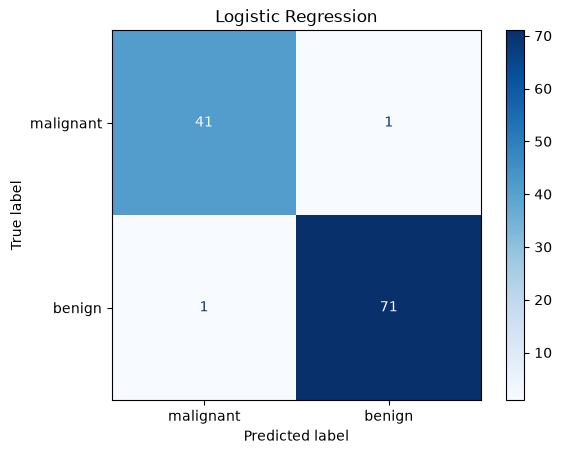

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [13]:
log_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(random_state=RANDOM_STATE))]),
    {
        "clf__C": [0.01, 0.1, 1, 10, 100],
        "clf__solver": ["liblinear", "lbfgs"],
        "clf__max_iter": [2000, 5000],
        "scaler": [StandardScaler(), MinMaxScaler()],
    },
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    # scoring=make_scorer(recall_score, pos_label=0),
    scoring=make_scorer(weighted_recall)
)
log_grid.fit(X_train, y_train)
log_cv = summarize_grid(log_grid, "Logistic Regression")
log_metrics = evaluate(log_grid.best_estimator_, "Logistic Regression")

### Naive Bayes

Naive Bayes — best params: {'scaler': 'passthrough'}
Naive Bayes — best CV score: 0.9260


,max,mean
param_scaler,,
passthrough,0.9260,0.9260
MinMaxScaler(),0.9218,0.9218
StandardScaler(),0.9218,0.9218


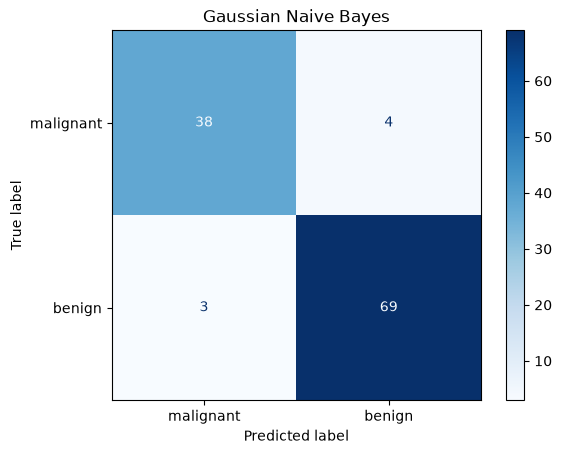

              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [14]:
nb_grid = GridSearchCV(Pipeline([("scaler", StandardScaler()), ("clf", GaussianNB())]),
            {
                "scaler": [StandardScaler(), MinMaxScaler(), "passthrough"],
            },
            cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
            scoring=make_scorer(weighted_recall),
        )
nb_grid.fit(X_train,y_train)
nb_cv = summarize_grid(nb_grid, "Naive Bayes")
naive_metrics = evaluate(nb_grid.best_estimator_, "Gaussian Naive Bayes")

### Perceptron

Perceptron — best params: {'clf__alpha': 0.0001, 'clf__max_iter': 1000, 'clf__penalty': 'elasticnet', 'scaler': StandardScaler()}
Perceptron — best CV score: 0.9577


,max,mean
param_scaler,,
StandardScaler(),0.9577,0.9373
MinMaxScaler(),0.9514,0.9074


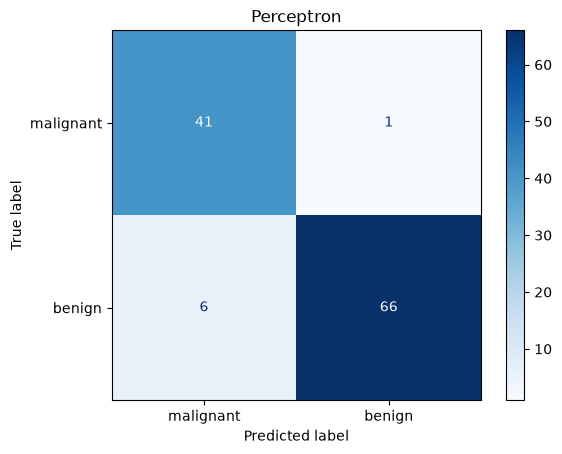

              precision    recall  f1-score   support

   malignant       0.87      0.98      0.92        42
      benign       0.99      0.92      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.95      0.94       114
weighted avg       0.94      0.94      0.94       114



In [15]:
per_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("clf", Perceptron(random_state=RANDOM_STATE))]),
    {
        "clf__penalty": [None, "l2", "l1", "elasticnet"],
        "clf__alpha": [0.0001, 0.001, 0.01],
        "clf__max_iter": [1000, 2000],
        "scaler": [StandardScaler(), MinMaxScaler()],
    },
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    # scoring=make_scorer(recall_score, pos_label=0),
    scoring=make_scorer(weighted_recall)
)
per_grid.fit(X_train, y_train)
per_cv = summarize_grid(per_grid, "Perceptron")
per_metrics = evaluate(per_grid.best_estimator_, "Perceptron")


### Support Vector Machine, SVM

SVM — best params: {'clf__C': 10, 'clf__gamma': 'scale', 'clf__kernel': 'rbf', 'scaler': MinMaxScaler()}
SVM — best CV score: 0.9711


,max,mean
param_scaler,,
MinMaxScaler(),0.9711,0.9316
StandardScaler(),0.9662,0.9551
passthrough,0.9521,0.7900


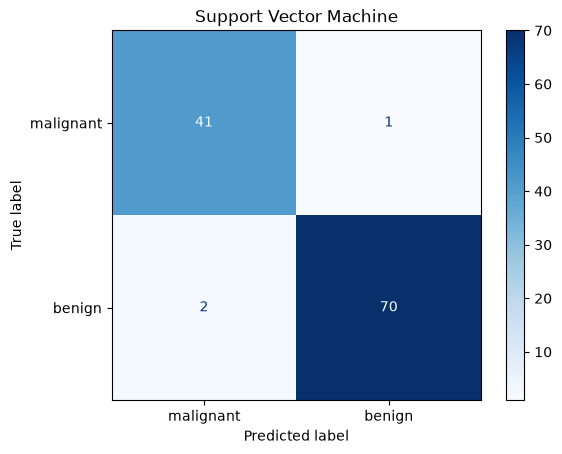

              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [16]:
svm_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("clf", SVC())]),
    {
        "clf__kernel": ["linear", "rbf"],
        "clf__C": [0.1, 1, 10, 100],
        "clf__gamma": ["scale", "auto"],
        "scaler": [StandardScaler(), MinMaxScaler(), "passthrough"],
    },
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    # scoring=make_scorer(recall_score, pos_label=0),
    scoring=make_scorer(weighted_recall)
)
svm_grid.fit(X_train, y_train)
svm_cv = summarize_grid(svm_grid, "SVM")
svm_metrics = evaluate(svm_grid.best_estimator_, "Support Vector Machine")

### Decision Tree Classifier

Decision Tree — best params: {'clf__ccp_alpha': 0.0, 'clf__class_weight': None, 'clf__criterion': 'gini', 'clf__max_depth': None, 'clf__min_samples_leaf': 20}
Decision Tree — best CV score: 0.9374


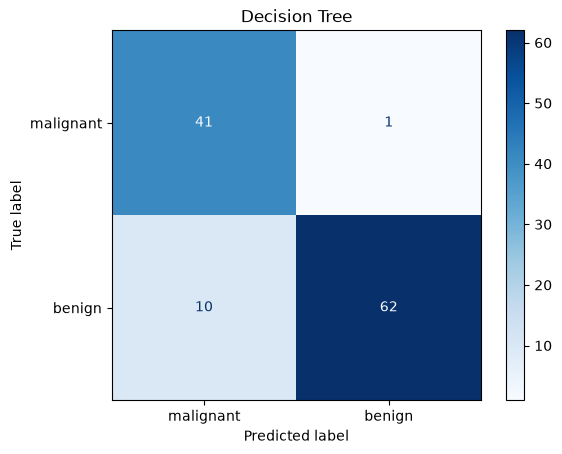

              precision    recall  f1-score   support

   malignant       0.80      0.98      0.88        42
      benign       0.98      0.86      0.92        72

    accuracy                           0.90       114
   macro avg       0.89      0.92      0.90       114
weighted avg       0.92      0.90      0.90       114



In [17]:
dt_grid = GridSearchCV(
    Pipeline([("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    {
        "clf__criterion": ["gini", "entropy"],
        "clf__max_depth": [None, 3, 5, 10],
        "clf__ccp_alpha": [0.0, 0.001, 0.01],
        "clf__min_samples_leaf": [1, 5, 10, 20],
        "clf__class_weight": [None, "balanced"],
    },
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    # scoring=make_scorer(recall_score, pos_label=0),
    scoring=make_scorer(weighted_recall)
)
dt_grid.fit(X_train, y_train)
dt_cv = summarize_grid(dt_grid, "Decision Tree")
dt_metrics = evaluate(dt_grid.best_estimator_, "Decision Tree")

### K-Nearest Neighbors, KNN

KNN — best params: {'clf__n_neighbors': 7, 'clf__weights': 'uniform', 'scaler': MinMaxScaler()}
KNN — best CV score: 0.9736


,max,mean
param_scaler,,
MinMaxScaler(),0.9736,0.9707
StandardScaler(),0.9648,0.9630
passthrough,0.9429,0.9355


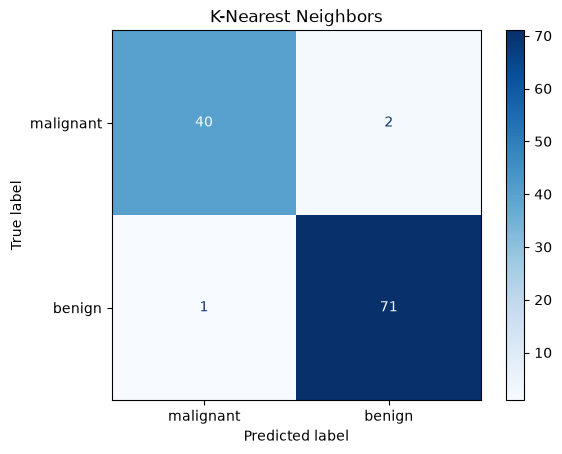

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [18]:
knn_grid = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
    {
        "clf__n_neighbors": [3, 5, 7, 9, 11, 13],
        "clf__weights": ["uniform", "distance"],
        "scaler": [StandardScaler(), MinMaxScaler(), "passthrough"],
    },
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    # scoring=make_scorer(recall_score, pos_label=0),
    # scoring=make_scorer(weighted_recall)##?
)
knn_grid.fit(X_train, y_train)
knn_cv = summarize_grid(knn_grid, "KNN")
knn_metrics = evaluate(knn_grid.best_estimator_, "K-Nearest Neighbors")

### Comparison

,accuracy,precision,recall,f1_score,recall_malignant,weighted_recall
Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9762,0.9802
SVM,0.9737,0.9859,0.9722,0.9790,0.9762,0.9746
KNN,0.9737,0.9726,0.9861,0.9793,0.9524,0.9659
Perceptron,0.9386,0.9851,0.9167,0.9496,0.9762,0.9524
Decision Tree,0.9035,0.9841,0.8611,0.9185,0.9762,0.9302
Naive Bayes,0.9386,0.9452,0.9583,0.9517,0.9048,0.9262


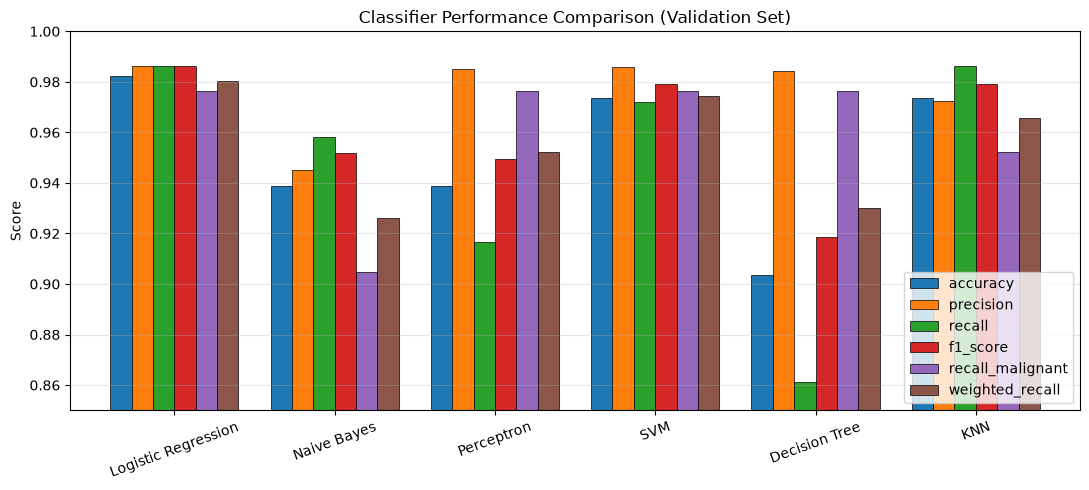

Logistic Regression    0.9781 ± 0.0156
Naive Bayes            0.9246 ± 0.0553
Perceptron             0.9619 ± 0.0423
SVM                    0.9676 ± 0.0187
Decision Tree          0.9211 ± 0.0537
KNN                    0.9675 ± 0.0282


In [19]:
from sklearn.model_selection import cross_val_score
results = pd.DataFrame({
    "Logistic Regression": log_metrics,
    "Naive Bayes": naive_metrics,
    "Perceptron": per_metrics,
    "SVM": svm_metrics,
    "Decision Tree": dt_metrics,
    "KNN": knn_metrics,
}).T

# display(results.round(4))
results["weighted_recall"] = 0.6 * results["recall_malignant"] + 0.4 * results["recall"]
display(results.sort_values("weighted_recall", ascending=False).round(4))

ax = results.plot(kind="bar", figsize=(11, 5), rot=20, width=0.8,
                  edgecolor="black", linewidth=0.5)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel("Score")
ax.set_title("Classifier Performance Comparison (Validation Set)")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

models = {
    "Logistic Regression": log_grid.best_estimator_,
    "Naive Bayes": nb_grid.best_estimator_,
    "Perceptron": per_grid.best_estimator_,
    "SVM": svm_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_,
    "KNN": knn_grid.best_estimator_,
}

cv10 = StratifiedKFold(10, shuffle=True, random_state=RANDOM_STATE)
scorer = make_scorer(weighted_recall)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv10, scoring=scorer)
    print(f"{name:<22} {scores.mean():.4f} ± {scores.std():.4f}")